# 04 – Validation, Outliers, Scaling & Metrics (M4)
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Regression – predict **`Days for shipping (real)`** at order placement.
**Owner:** M4 (Numeric prep & Evaluation)

### What this notebook does
1. Defines the team's **validation design** and **metrics**, and proves the validation is sound.
2. Checks **outliers and skew** in the model's numeric features and decides whether treatment is needed.
3. Chooses the **scaling** for each type of model (linear, distance-based, tree) with cross-validation.
4. Scores the baselines and the team's features with all metrics – the reference for PE2.

### Input and output
| Input | Output |
|---|---|
| `data/processed/train_fe.csv`, `test_fe.csv` (M2), `results/m3_selection.json` (M3) | `results/m4_preprocessing.json`, rows in `results/experiments.csv`, charts in `reports/figures/m4/` |

**Runtime:** KNN is slow on 100k+ rows, so KNN experiments use 30% of the orders. Allow several minutes for Step 4.

## Step 0 – Setup
### 0.1 Imports and paths

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "m4"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"
GROUP = "Order Id"
SEED = 42
KNN_ORDER_FRAC = 0.3

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

### 0.2 The team's metrics and validation functions
Every member evaluates with the same folds, the same metrics and the same log, so results are directly comparable.

| Metric | Meaning |
|---|---|
| **MAE** (primary) | average error in days – "on average, off by 1.2 days" |
| **RMSE** | punishes large misses more |
| **R²** | share of variation explained (0 = no better than predicting the average) |
| **MedAE** | typical error, not pulled up by a few big misses |
| **within_1_day_%** | % of orders predicted within ±1 day – business-friendly |
| **bias** | average (prediction − truth): + means predicts too slow, − too fast |

`cv_evaluate` trains a **fresh copy** (`clone`) of the pipeline in every fold, so nothing learned in one fold leaks into another.

In [2]:
METRICS = ["MAE", "RMSE", "R2", "MedAE", "within_1_day_%", "bias"]

def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred),
            "MedAE": median_absolute_error(y_true, y_pred),
            "within_1_day_%": float((np.abs(err) <= 1).mean() * 100),
            "bias": float(err.mean())}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits, return_predictions=False):
    rows, oof = [], np.full(len(y), np.nan)
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict(X.iloc[va])
        oof[va] = pred
        rows.append({"fold": i, **regression_metrics(y.iloc[va], pred)})
    per_fold = pd.DataFrame(rows)
    summary = {m: per_fold[m].mean() for m in METRICS}
    summary["MAE_std"] = per_fold["MAE"].std()
    return (summary, per_fold, oof) if return_predictions else (summary, per_fold)

def log_experiment(row, path=RESULTS_DIR / "experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

### 0.3 The preprocessor from M3's plan, plus scaling
Same encoding as M3 (rebuilt from `m3_selection.json`), then an optional scaler on **all** columns, then the model.

In [3]:
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="continuous", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

## Step 1 – Load the data, M3's plan and the folds

In [4]:
m3 = json.loads((RESULTS_DIR / "m3_selection.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]

train = pd.read_csv(PROCESSED_DIR / "train_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = make_cv(X, y, groups)

print(f"Train: {len(X):,} rows, {groups.nunique():,} orders")
print("Features:", FEATURES)
print("Encoding plan:", {k: v for k, v in PLAN.items() if v})

Train: 138,098 rows, 50,318 orders
Features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']
Encoding plan: {'numeric': ['Order Item Quantity', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend'], 'onehot': ['Shipping Mode', 'Market', 'Customer Segment'], 'target': ['Order Country', 'Category Name'], 'high_card_strategy': 'target'}


## Step 2 – Validation design
### 2.1 Check every fold
**Grouped:** `orders_in_both` must be 0. **Stratified:** every fold should have almost the same mean and spread of shipping days as the
whole training set – the regression version of a class-balance check.

In [5]:
fold_rows = []
for i, (tr, va) in enumerate(cv_splits):
    fold_rows.append({"fold": i, "train_rows": len(tr), "val_rows": len(va), "val_orders": groups.iloc[va].nunique(),
                      "val_mean_days": y.iloc[va].mean(), "val_std_days": y.iloc[va].std(),
                      "orders_in_both": len(set(groups.iloc[tr]) & set(groups.iloc[va]))})
folds = pd.DataFrame(fold_rows)
print(f"Whole training set: mean {y.mean():.3f}, std {y.std():.3f}")
folds.round(3)

Whole training set: mean 3.500, std 1.626


,fold,train_rows,val_rows,val_orders,val_mean_days,val_std_days,orders_in_both
0,0,110436,27662,10064,3.494,1.626,0
1,1,110497,27601,10064,3.496,1.632,0
2,2,110590,27508,10064,3.507,1.632,0
3,3,110584,27514,10063,3.493,1.619,0
4,4,110285,27813,10063,3.509,1.620,0


### 2.2 Target distribution per fold
The lines should lie on top of each other.

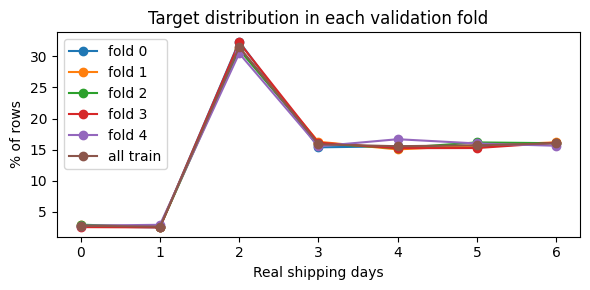

In [6]:
dist = pd.DataFrame({f"fold {i}": y.iloc[va].value_counts(normalize=True).sort_index() * 100 for i, (_, va) in enumerate(cv_splits)})
dist["all train"] = y.value_counts(normalize=True).sort_index() * 100
ax = dist.plot(marker="o", figsize=(6, 3))
ax.set_xlabel("Real shipping days"); ax.set_ylabel("% of rows"); ax.set_title("Target distribution in each validation fold")
show(ax.figure, "01_fold_distributions")

### 2.3 Why grouping matters: plain vs grouped folds
The same KNN model is scored with a **plain random KFold** and with the **grouped folds**. With the plain split, other items of the
same order (same features, same target) sit in the training part – KNN finds them as neighbours and copies their answer.
The plain score looks better, but it is **leakage**.

In [7]:
knn_orders = pd.Series(groups.unique()).sample(frac=KNN_ORDER_FRAC, random_state=SEED)
k_mask = groups.isin(knn_orders).to_numpy()
Xk, yk, gk = X[k_mask].reset_index(drop=True), y[k_mask].reset_index(drop=True), groups[k_mask].reset_index(drop=True)
cv_k_grouped = make_cv(Xk, yk, gk)
cv_k_plain = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(Xk))

knn = build_full_pipeline(KNeighborsRegressor(n_neighbors=15, n_jobs=-1), PLAN, scaler="standard")
plain_s, _ = cv_evaluate(knn, Xk, yk, cv_k_plain)
group_s, _ = cv_evaluate(knn, Xk, yk, cv_k_grouped)
pd.DataFrame({"plain KFold (leaky)": plain_s, "grouped (correct)": group_s}).loc[["MAE", "RMSE", "R2", "within_1_day_%"]].round(4)

,plain KFold (leaky),grouped (correct)
MAE,0.9729,1.0468
RMSE,1.2618,1.3525
R2,0.3992,0.3095
within_1_day_%,55.3653,52.6210


## Step 3 – Outliers and skew
### 3.1 Numeric columns: skew and outliers
The model's numeric features are compared with the money columns (not model features) for context.
IQR rule: an outlier lies more than 1.5 × IQR outside the 25th–75th percentile range.

In [8]:
def iqr_share(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

context = [c for c in ["Sales", "Benefit per order", "Order Item Discount"] if c in X.columns]
cols = PLAN["numeric"] + context
skew_table = pd.DataFrame({
    "in_model": [c in PLAN["numeric"] for c in cols],
    "skew": [X[c].skew() for c in cols],
    "outliers_%": [iqr_share(X[c]) for c in cols],
    "min": [X[c].min() for c in cols],
    "max": [X[c].max() for c in cols],
}, index=cols)
skew_table.round(2)

,in_model,skew,outliers_%,min,max
Order Item Quantity,True,0.88,0.00,1.00,5.00
order_weekday,True,-0.01,0.00,0.00,6.00
order_month,True,0.07,0.00,1.00,12.00
order_hour,True,0.00,0.00,0.00,23.00
order_quarter,True,0.09,0.00,1.00,4.00
is_weekend,True,0.95,0.00,0.00,1.00
Sales,False,2.88,0.27,9.99,1999.99
Benefit per order,False,-4.43,10.40,-4274.98,911.80
Order Item Discount,False,3.10,4.19,0.00,500.00


### 3.2 Distribution of the model's numeric features
Quantity and the date parts have small, fixed ranges (e.g. quantity 1–5, month 1–12, hour 0–23).

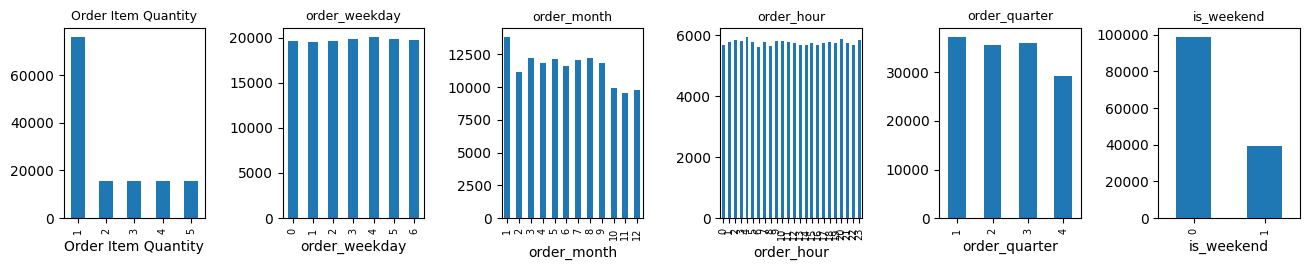

In [9]:
num = PLAN["numeric"]
fig, axes = plt.subplots(1, len(num), figsize=(2.2 * len(num), 2.8))
for ax, c in zip(np.atleast_1d(axes), num):
    X[c].value_counts().sort_index().plot.bar(ax=ax)
    ax.set_title(c, fontsize=9); ax.tick_params(axis="x", labelsize=7)
show(fig, "02_model_numeric_features")

### 3.3 Would clipping change the model's features?
Clipping (winsorising) caps values at the 1st and 99th percentiles. If it changes almost no rows, the features have no harmful
outliers and **no treatment is needed**. The skewed money columns are not model features, so they need no treatment either.

In [10]:
clip_effect = {}
for c in num:
    lo, hi = X[c].quantile([0.01, 0.99])
    clip_effect[c] = ((X[c] < lo) | (X[c] > hi)).mean() * 100
clip_effect = pd.Series(clip_effect, name="rows_changed_by_clipping_%").round(2)
OUTLIER_DECISION = "none" if (clip_effect < 2).all() and (skew_table.loc[num, "skew"].abs() < 1).all() else "review"
print("Outlier treatment decision:", OUTLIER_DECISION)
clip_effect.to_frame()

Outlier treatment decision: none


,rows_changed_by_clipping_%
Order Item Quantity,0.0
order_weekday,0.0
order_month,0.0
order_hour,0.0
order_quarter,0.0
is_weekend,0.0


## Step 4 – Choose the scaling for each type of model
### 4.1 Cross-validated comparison
- **Ridge** (linear): scaling gives stable, comparable coefficients and fair regularisation.
- **KNN** (distance-based): distances depend directly on each column's range, so scaling usually matters a lot.
- **HistGB** (tree): splits on thresholds, so scaling should make no difference – checked once.

In [11]:
SCALER_OPTIONS = ["none", "standard", "robust", "minmax"]
rows = []
for sc in SCALER_OPTIONS:
    s, _ = cv_evaluate(build_full_pipeline(Ridge(alpha=1.0), PLAN, sc), X, y, cv_splits)
    rows.append({"model": "Ridge", "scaler": sc, **s})
    s, _ = cv_evaluate(build_full_pipeline(KNeighborsRegressor(n_neighbors=15, n_jobs=-1), PLAN, sc), Xk, yk, cv_k_grouped)
    rows.append({"model": "KNN (30% orders)", "scaler": sc, **s})
for sc in ["none", "standard"]:
    s, _ = cv_evaluate(build_full_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=SEED), PLAN, sc), X, y, cv_splits)
    rows.append({"model": "HistGB (tree)", "scaler": sc, **s})
scale_results = pd.DataFrame(rows)
scale_results[["model", "scaler", "MAE", "MAE_std", "RMSE", "R2", "within_1_day_%"]].round(4)

,model,scaler,MAE,MAE_std,RMSE,R2,within_1_day_%
0,Ridge,none,0.9960,0.0092,1.2720,0.3878,52.0949
1,KNN (30% orders),none,1.3014,0.0187,1.5463,0.0974,42.7303
2,Ridge,standard,0.9960,0.0092,1.2720,0.3878,52.0978
3,KNN (30% orders),standard,1.0468,0.0177,1.3525,0.3095,52.6210
4,Ridge,robust,0.9960,0.0092,1.2720,0.3878,52.0942
5,KNN (30% orders),robust,1.0987,0.0183,1.3831,0.2779,50.0667
6,Ridge,minmax,0.9959,0.0092,1.2720,0.3879,52.0920
7,KNN (30% orders),minmax,1.0462,0.0185,1.3562,0.3057,52.9243
8,HistGB (tree),none,0.9836,0.0070,1.2760,0.3840,52.2159
9,HistGB (tree),standard,0.9836,0.0070,1.2760,0.3840,52.2159


### 4.2 Comparison chart

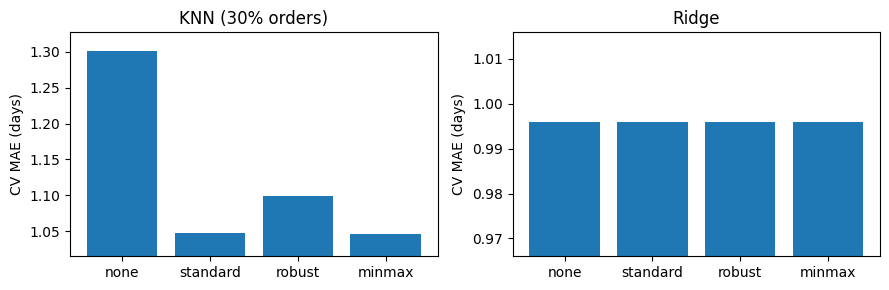

In [12]:
pivot = scale_results[scale_results["model"] != "HistGB (tree)"].pivot(index="scaler", columns="model", values="MAE").loc[SCALER_OPTIONS]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, m in zip(axes, pivot.columns):
    ax.bar(pivot.index, pivot[m]); ax.set_title(m); ax.set_ylabel("CV MAE (days)")
    ax.set_ylim(pivot[m].min() * 0.97, pivot[m].max() * 1.02)
show(fig, "03_scaling_comparison")

### 4.3 Decision per model family
Lowest MAE wins. If two options are within the fold-to-fold `MAE_std`, the difference is not meaningful – prefer the simpler one.

In [13]:
def best_scaler(model):
    r = scale_results[scale_results["model"] == model].sort_values("MAE").iloc[0]
    return {"scaler": r["scaler"], "cv_MAE": round(float(r["MAE"]), 4)}

tree = scale_results[scale_results["model"] == "HistGB (tree)"].set_index("scaler")["MAE"]
CHOICE = {
    "linear (Ridge / Linear Regression)": best_scaler("Ridge"),
    "distance (KNN)": best_scaler("KNN (30% orders)"),
    "tree (Decision Tree / Random Forest / XGBoost)": {"scaler": "none", "cv_MAE": round(float(tree["none"]), 4)},
}
print(f"HistGB MAE without scaling {tree['none']:.4f} vs with scaling {tree['standard']:.4f}")
pd.DataFrame(CHOICE).T

HistGB MAE without scaling 0.9836 vs with scaling 0.9836


,scaler,cv_MAE
linear (Ridge / Linear Regression),minmax,0.9959
distance (KNN),minmax,1.0462
tree (Decision Tree / Random Forest / XGBoost),none,0.9836


## Step 5 – Metrics in use: baselines and the team's features
### 5.1 All six metrics
The two baselines every model must beat, and the team's features with a default (untuned) linear and tree model.
Tuning comes in PE2 – this is the starting point.

In [14]:
mode_plan = {"numeric": [], "onehot": ["Shipping Mode"], "onehot_rare": [], "target": []}
candidates = {
    "Baseline: predict the mean": build_full_pipeline(DummyRegressor(strategy="mean"), PLAN),
    "Baseline: mean per Shipping Mode": build_full_pipeline(Ridge(alpha=1.0), mode_plan, "standard"),
    "Team features: Ridge": build_full_pipeline(Ridge(alpha=1.0), PLAN, CHOICE["linear (Ridge / Linear Regression)"]["scaler"]),
    "Team features: HistGB (default)": build_full_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=SEED), PLAN),
}
res_rows, per_fold_all, oof = [], {}, {}
for name, pipe in candidates.items():
    summary, per_fold, oof[name] = cv_evaluate(pipe, X, y, cv_splits, return_predictions=True)
    per_fold_all[name] = per_fold
    res_rows.append({"model": name, **summary})
metric_table = pd.DataFrame(res_rows).set_index("model")
metric_table[METRICS + ["MAE_std"]].round(4)

,MAE,RMSE,R2,MedAE,within_1_day_%,bias,MAE_std
model,,,,,,,
Baseline: predict the mean,1.4276,1.6259,-0.0000,1.4997,31.4019,0.0000,0.0062
Baseline: mean per Shipping Mode,0.9867,1.2710,0.3888,0.9957,52.0595,0.0000,0.0081
Team features: Ridge,0.9959,1.2720,0.3879,0.9926,52.0920,0.0003,0.0092
Team features: HistGB (default),0.9836,1.2760,0.3840,0.9826,52.2159,-0.0002,0.0070


### 5.2 Per-fold scores (stability)
Similar scores in every fold mean the cross-validation estimate is reliable.

In [15]:
per_fold_all["Team features: HistGB (default)"].round(4)

,fold,MAE,RMSE,R2,MedAE,within_1_day_%,bias
0,0,0.9860,1.2808,0.3796,0.9853,52.2703,0.0001
1,1,0.9859,1.2781,0.3870,0.9800,52.3206,-0.0075
2,2,0.9795,1.2690,0.3951,0.9821,52.5338,-0.0064
3,3,0.9924,1.2855,0.3697,0.9953,50.8432,0.0298
4,4,0.9741,1.2667,0.3887,0.9700,53.1119,-0.0168


### 5.3 Error distribution
The spread of errors is what PE2 models must reduce; a lopsided shape would show bias.

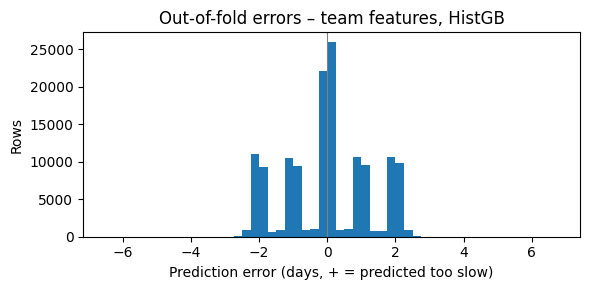

In [16]:
err = oof["Team features: HistGB (default)"] - y.to_numpy()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(err, bins=np.arange(-6.5, 7, 0.25))
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Prediction error (days, + = predicted too slow)"); ax.set_ylabel("Rows")
ax.set_title("Out-of-fold errors – team features, HistGB")
show(fig, "04_error_distribution")

## Step 6 – Save the decision and log the experiments
In PE2 every member builds their model with `build_full_pipeline(model, PLAN, scaler)` and takes the scaler for their model's family from this file.

In [17]:
decision = {
    "target": TARGET,
    "features": FEATURES,
    "validation": "StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), grouped by Order Id, stratified on the target",
    "metrics": METRICS,
    "primary_metric": "MAE",
    "outlier_treatment": OUTLIER_DECISION,
    "scaler_by_model_family": CHOICE,
    "reference_cv_MAE": metric_table["MAE"].round(4).to_dict(),
}
(RESULTS_DIR / "m4_preprocessing.json").write_text(json.dumps(decision, indent=2), encoding="utf-8")

for _, r in scale_results.iterrows():
    log_experiment({"owner": "M4", "experiment": f"scaler_{r['scaler']}", "model": r["model"], "n_features": len(FEATURES),
                    **{m: r[m] for m in METRICS}, "MAE_std": r["MAE_std"]})
for name, r in metric_table.iterrows():
    log_experiment({"owner": "M4", "experiment": "reference", "model": name, "n_features": len(FEATURES),
                    **{m: r[m] for m in METRICS}, "MAE_std": r["MAE_std"]})
print("Saved m4_preprocessing.json; experiments.csv now has", len(pd.read_csv(RESULTS_DIR / "experiments.csv")), "rows")

Saved m4_preprocessing.json; experiments.csv now has 79 rows


## Step 7 – Final check on the test set (transform only)
Nothing is fitted on the test set. This only proves the chosen preprocessing runs end to end for every model family.
Test **scores** are produced once, in PE2, for the final model comparison.

In [18]:
test = pd.read_csv(PROCESSED_DIR / "test_fe.csv")
if CATEGORY_COL == "Category Id":
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
X_te = test.drop(columns=[TARGET])
checks = {}
for family, opt in CHOICE.items():
    prep = build_full_pipeline(DummyRegressor(), PLAN, opt["scaler"])[:-1].fit(X, y)   # fitted on TRAIN
    Xt_te = prep.transform(X_te)                                                        # test only transformed
    checks[family] = {"scaler": opt["scaler"], "test_matrix": Xt_te.shape, "missing": bool(np.isnan(Xt_te).any())}
pd.DataFrame(checks).T

,scaler,test_matrix,missing
linear (Ridge / Linear Regression),minmax,"(34667, 20)",False
distance (KNN),minmax,"(34667, 20)",False
tree (Decision Tree / Random Forest / XGBoost),none,"(34667, 20)",False


## Step 8 – Viva summary

In [19]:
print(f'''
VALIDATION   5-fold StratifiedGroupKFold by Order Id | shared orders train/val: {int(folds["orders_in_both"].sum())}
FOLD BALANCE val mean days {folds["val_mean_days"].min():.3f}-{folds["val_mean_days"].max():.3f} (whole train {y.mean():.3f})
GROUPING     KNN plain KFold MAE {plain_s["MAE"]:.4f} vs grouped {group_s["MAE"]:.4f} (plain is optimistic)
OUTLIERS     model features need treatment: {OUTLIER_DECISION}
SCALING      linear: {CHOICE["linear (Ridge / Linear Regression)"]["scaler"]} | KNN: {CHOICE["distance (KNN)"]["scaler"]} | trees: none
BASELINES    mean {metric_table.loc["Baseline: predict the mean", "MAE"]:.4f} | Shipping Mode {metric_table.loc["Baseline: mean per Shipping Mode", "MAE"]:.4f}
TEAM (untuned) Ridge {metric_table.loc["Team features: Ridge", "MAE"]:.4f} | HistGB {metric_table.loc["Team features: HistGB (default)", "MAE"]:.4f} MAE
''')


VALIDATION   5-fold StratifiedGroupKFold by Order Id | shared orders train/val: 0
FOLD BALANCE val mean days 3.493-3.509 (whole train 3.500)
GROUPING     KNN plain KFold MAE 0.9729 vs grouped 1.0468 (plain is optimistic)
OUTLIERS     model features need treatment: none
SCALING      linear: minmax | KNN: minmax | trees: none
BASELINES    mean 1.4276 | Shipping Mode 0.9867
TEAM (untuned) Ridge 0.9959 | HistGB 0.9836 MAE



**My contribution in one sentence:** I designed and verified the grouped, stratified cross-validation, checked outliers and chose the
scaling for each type of model with cross-validation, and built the metrics the whole team evaluates with.